<a href="https://colab.research.google.com/github/ChettoKun/sys_eth_plant/blob/main/Planta_de_concentraci%C3%B3n_de_etanol_con_integraci%C3%B3n_energ%C3%A9tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Instalamos biosteam
%pip install biosteam

# **Simulación del proceso**

>>>>>>>>>>Iniciando simulación del proceso.....
>>>>>>✅ !Convergencia exitosa! El balance ha finalizado.

========TABLA DE BALANCE DE MATERIA=====
                Temp (°C) Presión (bar) Flujo (kg/h) % Etanol  % Agua
ID Corriente                                                         
1-MOSTO             25.00          1.01      1000.00    10.0%   90.0%
s1                  25.00          4.05      1000.00    10.0%   90.0%
Vinazas-Retorno     91.29          3.04       998.08     9.9%   90.1%
3-Mosto-Pre         38.58          4.05      1000.00    10.0%   90.0%
Drenaje             30.00          3.00       200.00     0.0%  100.0%
Mezcla              92.00          4.05      1000.00    10.0%   90.0%
Mezcla-Bifásica     92.00          1.01      1000.00    10.0%   90.0%
Vapor caliente      91.29          1.01         1.92    52.2%   47.8%
Vinazas             91.29          1.01       998.08     9.9%   90.1%
Producto Final      25.00          1.01         1.92    52.2%   47.8%

 ========TAB

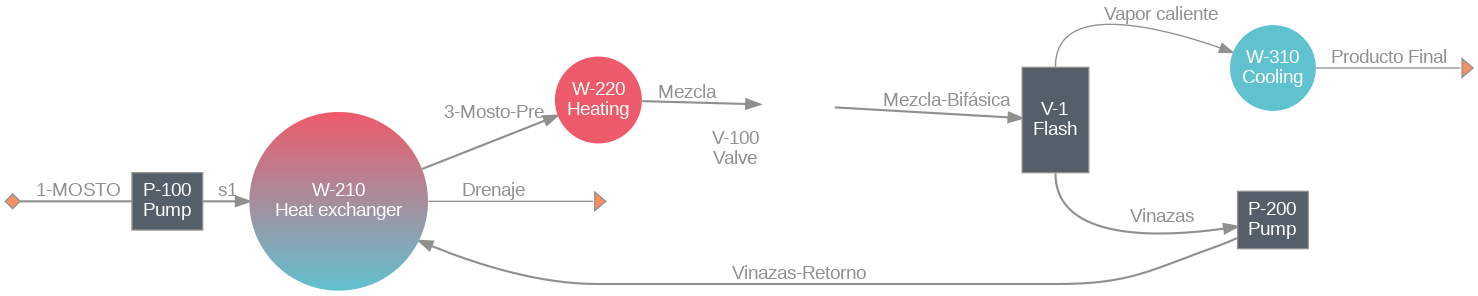

In [ ]:
#=================================================================
#Importamos las librerías
#=================================================================
import biosteam as bst                    #La librería principal para simulación de procesos con python
import thermosteam as tmo                 #Motor termodinámico (Propiedades físicas, equilibrio de fases, etc.)
import pandas as pd                       #Librería para manejar tablas
import os                                 #Librería para interactuar con el sistema operativo
from IPython.display import Image, display#Para mostrar las figuras de Biosteam

#=================================================================
#1. CONFIGURACIÓN DE LA SIMULACIÓN
#=================================================================
#Definimos los compuestos químicos a utilizar
chemicals=tmo.Chemicals(["Water","Ethanol"])

#Configuración termodinámica
#set_thermo: le dice a Biosteam-->para cualquier cálculo nuevo utiliza los compuestos que llamaste
#Por defecto Biosteam intentará usar modelos de actividad (NTRL o UNIFAC)
bst.settings.set_thermo(chemicals)

#=================================================================
#2. DEFINICIÓN DE CORRIENTES
#=================================================================
#-------------Alimentación----------------------------------------
mosto=bst.Stream("1-MOSTO",
                 Water=900, Ethanol=100, units="kg/hr",
                 T=25+273.15,
                 P=101325)

#------Corriente de reciclo---------------------------------------
vinazas_retorno=bst.Stream("Vinazas-Retorno",
                           Water=200, Ethanol=0, units="kg/hr",
                           T=95 + 273.15,
                           P=300000)

#==================================================================
#3. SELECCIÓN DE EQUIPOS
#==================================================================
#----------------------Bomba de alimentación (P-100)---------------
P100=bst.Pump("P-100", ins=mosto, P=4*101325)

#---------------------Intercambiador de calor (W-210)--------------
W210=bst.HXprocess("W-210",
                   ins=(P100-0, vinazas_retorno),
                   outs=("3-Mosto-Pre","Drenaje"),
                   phase0="l",phase1="l")

#Especificación de diseño
#Aquí ordenamos: "El mosto outs[0]" debe de salir exactamente a 85 °C
#Biosteam calculará cuánta energía se necesita y si la corriente de vinazas puede darla
W210.outs[0].T=85+273.15

#------------------Calentador auxiliar (W-220)----------------------
#Tipo: HXUtility, este método utiliza servicios externos (vapor de caldera) para calentar
W220=bst.HXutility("W-220",
                   ins=W210-0,
                   outs="Mezcla",
                   T=92+273.15)

#------------------Válvula de expansión------------------------------
V100=bst.IsenthalpicValve("V-100",
               ins=W220-0,
               outs="Mezcla-Bifásica",
               P=101325
               )

#-----------------Tanque separador (V-1)------------------------------
V1=bst.Flash("V-1",
             ins=V100-0,
             outs=("Vapor caliente", "Vinazas"),
             P=101325, Q=0)

#---------------Condensador--------------------------------------------
W310=bst.HXutility("W-310",
                   ins=V1-0,
                   outs="Producto Final",
                   T=25 + 273.15)

#-------------Bomba de reciclo-----------------------------------------
#Toma el líquido del fondo de flash y lo manda de regreso al W210
P200=bst.Pump("P-200",
              ins=V1-1,
              outs=vinazas_retorno,
              P=3*101325)

#=======================================================================
#4. SIMULACIÓN DEL PROCESO
#=======================================================================
eth_sys=bst.System("planta etanol", path=(P100,W210, W220,V100,V1, W310,P200))

print(">>>>>>>>>>Iniciando simulación del proceso.....")

try:
  #.simulate() ejecuta el método de Wegstein o Sustitución directa
  #para resolver los balances de materia y energía acoplados
  eth_sys.simulate()
  print(">>>>>>✅ !Convergencia exitosa! El balance ha finalizado.\n")
except Exception as e:
  print(f">>>>>-⚠ Advertencia: No se logró la convergencia. Error: {e}\n")

#=========================================================================
#5. REPORTE DE RESULTADOS (GENERACIÓN DE TABLAS)
#=========================================================================
#Esta función toma el sistema simulado y extre los datos importantes a un DataFrame

def generar_reporte(sistema):
  #---PARTE 1: TABLA DE CORRIENTES----
  datos_mat = []
  for s in sistema.streams:
    #Filtramos corrientes vacías para no ensuciar la tabla
    if s.F_mass > 0:
      #Programamos la lógica para mostrar los resultados en un diccionario
      datos_mat.append({
          "ID Corriente":s.ID,
          "Temp (°C)": f"{s.T-273.15:.2f}", #Kelvin a Celsius
          "Presión (bar)": f"{s.P/1e5:.2f}", #Pascales a bar
          "Flujo (kg/h)": f"{s.F_mass:.2f}",
          #Cálculo de procentajes másicos
          "% Etanol": f"{s.imass["Ethanol"]/s.F_mass:.1%}",
          "% Agua": f"{s.imass["Water"]/s.F_mass:.1%}"
      })

  df_mat = pd.DataFrame(datos_mat).set_index("ID Corriente")

  #----PARTE 2: TABLA DE ENERGÍA-----
  datos_en=[]
  for u in sistema.units:
    calor_kw = 0.0
    tipo_servicio = "-"
    #Caso especial: HXProcess (No tiene servicio externo, es recuperación interna)
    #if isintance(u, bst.HXProcess): --> nos pregunta ¿Es el objeto u un intercambiador de calor?
    if isinstance(u, bst.HXprocess):
      #Calculamos el calor ganado/perdio usando Entalpía (H)
      #H está en kJ/h, dividimos entre 3600 para obtener kW (kJ/s)
      calor_kw = (u.outs[0].H-u.ins[0].H)/3600
      tipo_servicio = "Recuperación Interna"

    #Caso estándar: Equipos con duty (Calor intercambiado con servicios auxiliares)
    #hasattr nos pregunta ¿Tiene el objeto (equipo) una propiedad llamada "duty"?
    #is not None nos asegura de que tenga valor numérico
    elif hasattr(u, "duty") and u.duty is not None:
      calor_kw = u.duty/3600
      #Definimos si es calentamiento o enfriamiento según el signo
      if calor_kw > 0.01: tipo_servicio = "Calentamiento (Vapor)"
      if calor_kw < -0.01: tipo_servicio = "Enfriamiento (Agua)"

    #Potencia Eléctrica (Motores de bombas)
    potencia = 0.0

    if hasattr(u, "power_utility") and u.power_utility:
      potencia = u.power_utility.rate

    #Solo agreamos el equipo a la tabla si consume energía relevante
    if abs(calor_kw) > 0.01:
      datos_en.append({
          "ID Equipo": u.ID,
          "Función": tipo_servicio,
          "Energía Térmica (kW)": f"{calor_kw:.2f}",
      })
    if potencia > 0.01:
      datos_en.append({
          "ID Equipo":u.ID,
          "Función":"Motor bomba",
          "Energía eléctrica (kW)": f"{potencia:.2f}"

      })

  df_en=pd.DataFrame(datos_en).set_index("ID Equipo")
  return df_mat, df_en

#Ejecutamos la función y obtenemos las tablas
tabla_materia, tabla_energia = generar_reporte(eth_sys)

#Imprimimos los resultados
print("========TABLA DE BALANCE DE MATERIA=====")
print(tabla_materia)
print("\n ========TABLA DE BALANCE DE ENERGIA=====")
print(tabla_energia)

#==========================================================
#6. ESQUEMA DEL PROCESO (VISUALIZACIÓN)
#==========================================================
print("\n====Diagrama de flujo ======")
try:
  nombre_archivo = "diagrama_etanol_final"
  eth_sys.diagram(file=nombre_archivo, format="png")

  #.display() muestra esa imagen generada aquí mismo en el cuaderno de colab
  display(Image(nombre_archivo + ".png"))
except Exception as e:
  print(f"Error al generar el diagrama: {e}")

# **Estudio Tecnoeconómico manual**

In [ ]:
#====================================================================
#MÓDULO DE EVALUACIÓN TÉCNICA Y ECONÓMICA
#====================================================================

#Objetivos
#1. Leer los tamaños de los equipos (Ingeniería de Detalle).
#2. Calcular cuánto cuesta la planta (CAPEX) usando el Factor de Lang
#3. Calcular cuánto cuesta operar la planta (OPEX).
#4. Determinar si el negocio es rentable (ROI y Payback)

print("\n>>>> INICIANDO MÓDULO DE ANÁLISIS INTEGRAL....")
#====================================================================
#PASO 0: VERIFICAMOS LA SIMULACIÓN
#====================================================================
#El costo de los equipos es función del tamaño
#Por ejemplo,
#- No puedes cotizar un tanque si no sabes su volumen
#- No puedes cotizar un intercambiador de calor si no sabes su área de transferencia

try:
  eth_sys.simulate()
except:
  pass #Si ya estaba simulado

#=====================================================================
#PASO 0.5: REPORTE DE INGENIERÍA DE DETALLE (PARÁMETROS DE DISEÑO)
#=====================================================================
#Aquí respondemos ¿Qué tan grandes son los equipos?
#Biosteam una vez que realiza los balances de materia y energía, hace el cálculo
#de los parámetros de diseño y los guarda en un objeto "design_results"

print("\n" + "="*60)
print(" Reporte de ingeniería de detalle (dimensionamiento)")
print("\n" + "="*60)

for equipo in eth_sys.units:
  #Usamos hasattr para preguntar ¿Este equipo tiene resultados de diseño?
  if hasattr(equipo, "design_results") and equipo.design_results:
    print(f"\n Equipo: {equipo.ID} ({equipo.__class__.__name__})")

    #BUCLE FOR: Recorreemos cada parámetro calculado (área, potencia, etc)
    for parametro, valor in equipo.design_results.items():
      val_str = f"{valor:,.2f}" if isinstance(valor, float) else str(valor)

      #Biosteam calcula en unidades americanas por defecto para el diseño
      unidad=""
      definicion=""

      if "Area" in parametro:
        unidad ="ft2"
        definicion="Área de transferencia de calor"
      elif "Power" in parametro or "duty" in parametro:
        unidad="HP"
        definicion="Potencia del motor"
      elif "Volume" in parametro:
        unidad="ft3"
        definicion="Volumen o capacidad del tanque"
      elif "Pressure" in parametro:
        unidad="psi"
        definicion="Caída de presión/Delta P"
      elif "Material" in parametro:
        unidad="" #El material es texto, no tiene unidad numérica
        definicion="(Material de Construcción-Afecta el costo)"

      #IMPRESIÓN FORMATEADA
      print(f"        {parametro:<25}: {val_str} {unidad:<5} {definicion}")

#====================================================================
#PASO 1: VARIABLES DE MERCADO (INPUTS EXTERNOS)
#====================================================================
#Son variables externas.  El ingeniero de diseño NO tiene control
#sobre ellas, las dicta el mercado internacional o los proveedores locales

precio_luz = 0.085 #$/kWh (Tarifa Industrial media -CFE)
precio_vapor = 0.025 #$/MJ (Costo por generar vapor: Gas natural + Agua)
precio_agua = 0.0005 #$/MJ (Costo de bombeo y químicos de torre de enfriamiento)
precio_mosto = 0.0005 #$/kg  (Costo de materia prima)
precio_etanol = 100.2 #$/kg (Precio de venta-Determina los ingresos)

#======================================================================
#PASO 2: CÁLCULO DE INVERSIÓN DE CAPITAL (CAPEX)
#======================================================================
#CAPEX (Capital Expenditures)
#Es la inversión inicial. El dinero que necesitas tener en el banco ANTES
#de empezar a producir la primera gota de mosto concentrado.

print("\n" + "="*60)
print(" Análisis de inversión (CAPEX)")
print("="*60)

costo_equipos=0.0

print("\n--A. COSTO DE COMPRA DE EQUIPOS (PRECIO FOB)---")
#Costo FOB (Free On Board)
#Es el costo de la máquina "puesta en la fábrica del vendedor"
#NO INCLUYE: Flete, Grúas, Instalación, tubería.....

#¿Cómo calcula el software?-->Formula de Williams
#Usa la "Ley de potencia" (Economy of scale):
#Costo=Costo_base*(Capacidad/Capacidad_base)^0.6
#Donde la potencia es un exponente que puede varía entre 0.3 y 1
for unidad in eth_sys.units:
  #Filtro
  if hasattr(unidad, "purchase_cost") and unidad.purchase_cost is not None:
    precio_individual = unidad.purchase_cost
    print(f"{unidad.ID:<10}: ${precio_individual:,.0f}")
    costo_equipos += precio_individual

#=========================================================================
#EL FACTOR DE LANG (HANS LANG, 1950)
#=========================================================================
#El factor de lang estima los "Costos de Planta instalada" (ISBL)
#Multiplicamos el costo de los equipos FOB por un factor.

#Desgloce del factor (Típico 4 para fluidos):
# +1.0: Equipos (lo que viene en el FOB)
# +0.4: Tuberías (Es muy caro)
# +0.35: Instrumentación y Control (Sensores, EP, EF, etc.)
# +0.1: Electrico (Subestaciones, Cables)
# +0.2: Obra civil (edificios, concreto)
# +0.3: Ingeniería y Supervisión
# +0.65: Contingencias y Costos de construcción
# =4.0 (Total aproximado)

factor_de_lang=4.0
inversion_total = costo_equipos*factor_de_lang

print(f" SUMA DE EQUIPOS (FOB) ${costo_equipos:,.2f}")
print(f" FACTO DE LANG (Instalación): x {factor_de_lang:,.2f}")
print(f" INVERSIÓN TOTAL ESTIMADA: ${inversion_total:,.2f} USD")

#==========================================================================
#PASO 3. CÁLCULO DE OPERACIÓN (OPEX)
#==========================================================================
#Definición: OPEX (Operating Expenditures)
#Es el costo de "mantener las luces encendidas". Se gasta hora tras hora.
#Incluye: Costos variables (Materia prima, Energía-servicios auxiliares) y Fijo (Mano de obra)

print("\n" + "="*60)
print(" ANÁLISIS OPERATIVO (OPEX Y FLUJO DE CAJA)")
print("\n" + "="*60)

#A. COSTO DE MATERIA PRIMA (VARIABLE)
#Flujo (kg/h)*Precio ($/kg)
gasto_mosto=mosto.F_mass*precio_mosto

#B. COSTO DE SERVICIOS (ENERGÍA)
#Suma manual del consumo de cada equipo de forma invidual
consumo_luz_kw = 0.0
consumo_calor_mj = 0.0
consumo_frio_mj = 0.0

for u in eth_sys.units:
  #1. Electricidad (Motores)
  if u.power_utility:
    consumo_luz_kw += u.power_utility.rate
  #2. Calor y frío (Intercambiadores)
  for hu in u.heat_utilities:
    #El duty en Biosteam suele estar en kJ/h
    #Lo convertimos entonces en MJ/h dividiendo entre 1000
    duty_mj=hu.duty/1000

    if duty_mj >0:
      consumo_calor_mj += duty_mj  #(+)Vapor (Calentamiento)
    elif duty_mj < 0:
      consumo_frio_mj += abs(duty_mj) #(-) Agua (Enfriamiento)

#Convertimos energía física en dinero ($)
costo_luz = consumo_luz_kw*precio_luz
costo_calor = consumo_calor_mj*precio_vapor
costo_frio = consumo_frio_mj*precio_agua
total_servicios = costo_luz + costo_calor + costo_frio

#C. VENTAS (INGRESOS BRUTOS)
ventas_etanol = W310.outs[0].F_mass*precio_etanol

#===================================================================
#PASO 4. RESULTADOS E INDICADORES DE RENTABILIDAD
#===================================================================
#Balance de caja por hora
ganancia_hora = ventas_etanol - (gasto_mosto + total_servicios)

print(f"      (-) Materia Prima:               ${gasto_mosto:,.4f}/h")
print(f"      (-) Electricidad:                ${costo_luz:,.4f}/h")
print(f"      (-) Vapor (Calentamiento)        ${costo_calor:,.4f}/h")
print(f"      (-) Agua (Enfriamiento)          ${costo_frio:,.4f}/h")
print(f"      ------------------------------------------------------")
print(f"       TOTAL GASTO (Salidas)           ${gasto_mosto + total_servicios:,.4f}/h")
print(f"\n    (+) VENTAS (Entradas)            ${ventas_etanol:,.4f}/h")
print(f"      ------------------------------------------------------")

#LÓGICA DE DIAGNÓSTICO FINAL
if ganancia_hora > 0:
  print(f" >>>>>FLUJO NETO:               ${ganancia_hora:,.4f}/h  (✅Ganancia)")
  #-----CÁLCULO DE ROI (RETORNO DE INVERSIÓN)---------
  #Definición: ROI (Return of Investment)
  #Fórmula: (Ganancial Anual/Inversión Total)*100
  #Nos dice el % de la inversión  que recuperaremos cada año

  #SUPUESTO: Año operativo de 330 días (7920 h).
  #Los restantes 35 días son para mantenimiento o limpieza
  horas_anuales= 7920
  ganancia_anual = horas_anuales*ganancia_hora

  if inversion_total > 0:
    roi = (ganancia_anual/inversion_total)*100

    #DEFINICIÓN: PAYBACK PERIOD (TIEMPO DE RECUPERACIÓN)
    #Años necesarios para que la suma de ganancia iguale a la inversión inicial
    tiempo_recuperacion = 100/roi

    print(f"\n     >>>>📊INDICADORES FINANCIEROS CLAVE:")
    print(f"           1. Ganancia Anual:          ${ganancia_anual:,.4f}/año")
    print(f"           2. ROI:                      {roi:,.1} % Anual")
    print(f"           3. Payback:                  {tiempo_recuperacion:,.4f} años")

    #Semáforo de inversión
    if roi > 25:
      print("                VEREDICTO: 🟢 EXCELENTE (Alta rentabilidad)")
    elif roi >10:
      print("                VEREDICTO: 🟡 ACEPTABLE (Rentabilidad estándar)")
    else:
      print("                VEREDICTO: 🔴 BAJO (Es mejor meter el dinero al banco)")
  else:
    print("   ☢ Error: Inversión es cero. Revise el costo de equipos")
else:
  print(f"   >>>>FLUJO NETO:          ${ganancia_hora:,.4f}/h (💔 PÉRDIDA)")
  print(f"       El proceso quema dinero. Posibles causas:")
  print(f"       1. Ineficiencia energética (estamos gastando demasiado vapor)")
  print(f"       2. Margen bruto negativo (Mosto es muy caro o etanol muy barato)")




>>>> INICIANDO MÓDULO DE ANÁLISIS INTEGRAL....

 Reporte de ingeniería de detalle (dimensionamiento)


 Equipo: P-100 (Pump)
        Type                     : Centrifugal       
        Ideal power              : 0.12       
        Flow rate                : 4.54       
        Efficiency               : 0.35       
        Power                    : 0.33 HP    Potencia del motor
        Head                     : 297.49       
        Motor size               : 0.33       

 Equipo: W-210 (HXprocess)
        Area                     : 295.93 ft2   Área de transferencia de calor
        Overall heat transfer coefficient: 0.50       
        Log-mean temperature difference: 5.00       
        Fouling correction factor: 1.00       
        Operating pressure       : 58.80       
        Total tube length        : 20       
        Shell side pressure drop : -3,975.00       

 Equipo: W-220 (HXutility)
        Area                     : 2.95 ft2   Área de transferencia de calor
      

# **Estudio tecnoecnómico con Biosteam**

In [ ]:
#===============================================================================
#MÓDULO DE INGENIERÍA ECONÓMICA (TEA)
#===============================================================================
import biosteam as bst
import pandas as pd
import numpy as np

print("\n >>>>>>🟢 CONFIGURANDO PRECIOS DE MERCADO")

#-------------------------------------------------------------------------------
#PASO 1: Definición de precios
#-------------------------------------------------------------------------------
#Aquí asignamos el valor del dinero a la Física y Química
#Sin esto, Biosteam calcula kilos y joules, pero no dolares

#1. Electricidad (Tarifa Industrial CFE)
#Biosteam tiene el objeto "PowerUtility" para la luz
#Unidades: Dolares por kWh ($/kWh)

bst.PowerUtility.price = 0.085
print(f"          Electricidad:            ${bst.PowerUtility.price:,.4f}/kWh")

#2. Vapor (Calentamiento)
#Buscamos el atributo "low_pressure_steam" (Vapor de baja presión)
#Unidades: Dólares por MJ de energía térmica ($/MJ)
vapor=bst.HeatUtility.get_agent("low_pressure_steam")
vapor.heat_transfer_price=0.025
print(f"          Vapor:                  ${vapor.heat_transfer_price:,.4f}/MJ")

#3. Agua para enfriamiento
#Buscamos el agente "cooling_water/cooling-water"
agua=bst.HeatUtility.get_agent("cooling_water")
agua.heat_transfer_price=0.0005
print(f"          Agua de enfriamiento:                  ${agua.heat_transfer_price:,.4f}/MJ")

#4. Materia prima (Mosto)
mosto.price=0.0000005 #$/kg
print(f"          Materia prima:                  ${mosto.price:,.4f}/MJ")

#5. Producto
producto =W310.outs[0]
producto.price=1.2 #$/kg
print(f"          Producto (Etanol):                  ${producto.price:,.4f}/MJ")

#Se corre aquí para que Biosteam al simular el proceso multiplique Flujo*Nuevos precios
eth_sys.simulate()

#------------------------------------------------------------------------------
#PARTE 1: Las reglas del juego - Diccionario financiero
#------------------------------------------------------------------------------
class TEA_Didactico(bst.TEA):
  #-----A. INVERSIÓN DE CAPITAL (CAPEX - Capital Expenditures
  def _DPI(self, installed_equipment_cost):
    #DPI (Directo Permanent Investment-->Inversión Permanente Directa)
    #Definición: Es el costo de comprar los equipos principales (Bombas, Reactores, Torres, etc..)
    #[DIFERENCIA VS MANUAL]: Generalmente este coincide con el manual
    #y ponerlos en el sitio. El precio de etoqueta de los equipos

    return self.purchase_cost

  def _TDC(self, DPI):
    #TDC: Total Depreciable Capital (Capital Total Depreciable)
    #Definición: Es la parte de la inversión que pierde valor con el tiempo (se hace vieja)
    #El gobienro nos permite restar este valor de nuestras ganancias futuras para menos impuestos.
    #[DIFERENCIA VS MANUAL]: El cálculo manual ignora impuestos, por lo tanto
    #ignora la depreciación. Aquí es vital para el flujo de efectivo

    return DPI

  def _FCI(self, TDC):
    #FCI: Fixed Capital Investment (Inversiín Fija de Capital)
    #Definición: Es el costo de la plnata lista para operar, pero sin arrancar
    #Incluye: Equipos + Tuberías + Cables + Edificios + Instalación, etc...
    #[DIFERENCIA VS MANUAL]: El código manual suele ignorar el costo de la obra civil y tuberías
    #Estre valor será 4 veces mayor que la suma simple del costo de los equipos.
    return self.purchase_cost*self.lang_factor

  def _TCI(self, FCI):
    #TCI: Total Capital Investment (Inversión Total del Proyecto)
    #Definición:  Es la inversión fija (FCI) + Capital de treabajo (Working capital)
    #¿Qué es el capital de trabajo?
    #Es el dinero en efectivo que debes tgener en la cuenta del banco en el día 1
    #Sirve para pagar nómina, la luz, materia prima al inicio,
    #antes de que los clientes te paguen las primeras facturas-
    #Aquí reservarmos un 5% extra  para  no quebrar en el arranque
    #[DIFERENCIA VS MANUAL]: El manual asume que puedes empezar con $0 pesos en la bolsa
    #Aquí reservamos el 5% del costo de inversión.
    return FCI + self.WC

  #------B. Costos de Operación (OPEX)-------------------------------------------
  def _FOC(self,FCI):
    #FOC: Fixed Operating Cost (Costos fijos de operación)
    #Definición: Gastos que pagas aunque la planta este parada.
    #Ejemplos: Seguros, Impuestos Prediales, Sueldo del gerente, vigilancia.
    #En ocasiones suele tomarse aproximadamente el 5% del FCI-
    return 0.0

  @property
  def VOC(self):
    #VOC: Variable Operating Cost (Costos de Operación Variables)
    #Definición: Gastos que dependen de cuanto produces.
    #Si produces el doble, gastas el doble:
    #1. Materia prima.
    #2. Servicios auxiliares (Utility_costo: Luz, Vapor, Agua, etc.)
    mat = getattr(self.system, "material_cost", 0)
    util = getattr(self.system, "utility_cost", 0)
    return mat + util

#-------------------------------------------------------------------------------
#PARTE 2: CONFIGURACIÓN DEL ESCENARIO (INPUTS)
#-------------------------------------------------------------------------------
#---------------------Descripción de parámetros---------------------------------

try:
  #Instanciamos el análisis económico con los datos de nuestro proceso
  tea =TEA_Didactico(
      system = eth_sys,

      #Tasa de descuento (IRR):
      IRR = 0.15,
      #IRR: Internal Rate of Return (Tasa interna de retorno)
      #[BIOSTEAM VS MANUAL]: El manual suma un dolar de hoy con un dolar del año 2045
      #Aquí, esta tasa (15%) "castiga" las ganancias futuras
      #Nos dice: "Ganar dinero en el 2045 vale mucho menos que ganar dinero hoy"

      duration = (2025, 2045), #20 años de vida del proyecto
      #-------Impuestos (Taxes)---------
      #Es el porcentaje que la empresa debe pagar al gobierno sobre su utilidad antes de impuestos
      income_tax=0.3,
      #[BIOSTEAM VS MANUAL]: El manual asume que el 100% de la ganancia por ventas es del dueño
      #Aquí, el gobierno (SAT) se lelva el 30% de cada dolar que gane el dueño.
      #Esto reduce drásticamente la rentabilidad real del proyecto.
      depreciation = "MACRS7", #Depreciación acelerada (7 años)
      #----TIEMPO MUERTO (CONSTRUCCIÓN)------------
      construction_schedule = (0.4,0.6),
      #[BIOSTEAM VS MANUAL]: El manual asume producción inmediata.
      #Aquí simulamos que tardamos 2 años en construir la planta (año 1 (40%) y año 2 (60%))
      #En estos años años solo sale dinero (gastos), no entra nada.

      startup_months = 6, #6 meses de arranque (curva de aprendizaje)
      startup_FOCfrac = 0.5, #Gastos reducidos durante el arranque
      startup_VOCfrac = 0.5,
      startup_salesfrac = 0.5, #Ventas reducidas durante el arranque
      operating_days = 330, #330 días operativos (1 mes de mantenimiento)
      lang_factor = 4.0, #Planta = 4 veces el costo de los equipos
      WC_over_FCI = 0.05, #5% de Capital de trabajo
      finance_interest = 0.0, #Sin deuda bancaria
      finance_years = 0.0,
      finance_fraction = 0.0,
    )

  print(">>>>>>⚙ Calculando indicadores financieros complejos....")
  producto = W310.outs[0] #Corriente de salida del producto (Etanol)

  #-----------------------------------------------------------------------------
  #PARTE 3: Cálculos y resultados comparativos
  #-----------------------------------------------------------------------------
  #Caso A: COSTO REAL
  #Definición: Precio mínimo para cubrir costos + impuestos + recuperación de inversión
  #Ganancia neta: $0
  tea.IRR = 0.0
  costo_produccion = tea.solve_price(producto)

  #Caso B: Precio meta
  #Definición: Precio neceario para dar un rendimiento del 15% anual a los socios
  tea.IRR = 0.15
  precio_venta = tea.solve_price(producto)

  #REPORTE FINAL
  print("\n" + "="*60)
  print("💰Glosario de resultados comparativos")
  print("="*60)

  print(f"1. COSTO REAL DE PRODUCCIÓN:                  ${costo_produccion:.2f}/kg")
  print("  [SIGNIFICADO]: Esto cuesta fabricar el producto sin incluimos:")
  print("   Materia prima + Luz + Impuestos + Recuperar la inversión de la planta")
  print("  [COMPARATIVA]: Este valor es más alto que el cálculo manual")

  print(f"\n2. PRECIO DE VENTA SUGERIDO:                ${precio_venta:.2f}/kg")
  print("  [SIGNIFICADO]: A esto debemos vender para que el negocio sea atractivo")
  print(f"  ----->MARGEN NECESARIO:                     ${precio_venta-costo_produccion}")
  print("="*60)

  #NPV
  print(f"3. NPV (Valor presente neto):                 ${tea.NPV:,.2f} USD")
  print("    [Net Present Value]: Suma de toda la riqueza generada en 20 años del proyecto")
  print("    pero traía a valor de hoy (descontada por inflación/riesgo)")
  print("    (+) = Riqueza/(-) = Destrucción de valor")

  #Payback (PBP)
  print(f"4. PBP (Tiempo de recuperación):            ${tea.PBP:.1f} años")
  print("     [Payback period]: Años que tardamops en recuperar la inversión inicial")
  print("     [COMPARATIVA]: En el manual era rápido. Aquí incluye:")
  print("     los 2 años muertos de cosntrucción de la planta y el pago impuestos")

  #ROI
  print(f"5. ROI (Retorno de inversión):              ${tea.ROI:.1f} %")
  print("     [Return of investment]: Tasa de interés efectiva que para el negocio")

  print("="*60)

  if tea.NPV>0:
    print(">>>>>>✅VEREDICTO: PROYECTO VIABLE. (Genera valor real)")
  else:
    print(">>>>>>❌VEREDICTO: PROYECTO NO RENTABLE. (Los costo ocultos comieron la ganancia)")

except Exception as e:
  print(f"❌ Error en el cálculo: {e}")




 >>>>>>🟢 CONFIGURANDO PRECIOS DE MERCADO
          Electricidad:            $0.0850/kWh
          Vapor:                  $0.0250/MJ
          Agua de enfriamiento:                  $0.0005/MJ
          Materia prima:                  $0.0000/MJ
          Producto (Etanol):                  $1.2000/MJ
>>>>>>⚙ Calculando indicadores financieros complejos....

💰Glosario de resultados comparativos
1. COSTO REAL DE PRODUCCIÓN:                  $321.17/kg
  [SIGNIFICADO]: Esto cuesta fabricar el producto sin incluimos:
   Materia prima + Luz + Impuestos + Recuperar la inversión de la planta
  [COMPARATIVA]: Este valor es más alto que el cálculo manual

2. PRECIO DE VENTA SUGERIDO:                $323.45/kg
  [SIGNIFICADO]: A esto debemos vender para que el negocio sea atractivo
  ----->MARGEN NECESARIO:                     $2.2724304637417845
3. NPV (Valor presente neto):                 $-29,535,139.90 USD
    [Net Present Value]: Suma de toda la riqueza generada en 20 años del proyecto
 

In [ ]:
tea.show()

TEA_Didactico: planta etanol
NPV: -29,535,140 USD at 15.0% IRR


In [ ]:
pd.set_option("display.max_columns", None)
tea.get_cashflow_table()

,Depreciable capital [MM$],Fixed capital investment [MM$],Working capital [MM$],Depreciation [MM$],Loan [MM$],Loan interest payment [MM$],Loan payment [MM$],Loan principal [MM$],Annual operating cost (excluding depreciation) [MM$],Sales [MM$],Tax [MM$],Incentives [MM$],Taxed earnings [MM$],Forwarded losses [MM$],Net earnings [MM$],Cash flow [MM$],Discount factor,Net present value (NPV) [MM$],Cumulative NPV [MM$]
2023,0.0188,0.0753,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.0753,1.15,-0.0865,-0.0865
2024,0.0282,0.113,0.00941,0,0,0,0,0,0,0,0,0,0,0,0,-0.122,1,-0.122,-0.209
2025,0,0,0,0.00672,0,0,0,0,3.65,0.0137,0,0,0,0,-3.65,-3.64,0.87,-3.17,-3.37
2026,0,0,0,0.0115,0,0,0,0,4.87,0.0183,0,0,0,-3.65,-4.87,-4.85,0.756,-3.67,-7.04
2027,0,0,0,0.00823,0,0,0,0,4.87,0.0183,0,0,0,-8.51,-4.86,-4.85,0.658,-3.19,-10.2
2028,0,0,0,0.00587,0,0,0,0,4.87,0.0183,0,0,0,-13.4,-4.86,-4.85,0.572,-2.78,-13
2029,0,0,0,0.0042,0,0,0,0,4.87,0.0183,0,0,0,-18.2,-4.86,-4.85,0.497,-2.41,-15.4
2030,0,0,0,0.0042,0,0,0,0,4.87,0.0183,0,0,0,-23.1,-4.86,-4.85,0.432,-2.1,-17.5
2031,0,0,0,0.0042,0,0,0,0,4.87,0.0183,0,0,0,-28,-4.86,-4.85,0.376,-1.82,-19.3
2032,0,0,0,0.0021,0,0,0,0,4.87,0.0183,0,0,0,-32.8,-4.86,-4.85,0.327,-1.59,-20.9
